# U-net

Segmentación semántica

<img src="./misc/u-net-architecture.png" width="75%">

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, utils
from torchvision.io import read_file, decode_jpeg, decode_png, ImageReadMode
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torchvision.io import read_image

In [2]:
# DATASET
import os

# read dataset for u-net
class Dataset(Dataset):
    def __init__(self, data_dir, label_dir):
        self.data_dir = data_dir
        self.label_dir = label_dir
        self.files = [os.path.splitext(f)[0] for f in os.listdir(data_dir)]
        self.transform = T.Resize((512, 512))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        # read image
        image = read_image(os.path.join(self.data_dir, file_name + ".png"), mode=ImageReadMode.RGB)
        
        # read mask
        mask = read_image(os.path.join(self.label_dir, file_name + ".png"), mode=ImageReadMode.GRAY)
        
        # resize
        image = self.transform(image)
        mask = self.transform(mask)
        
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)
        
        image = image / 255.0
        mask /= 255.0
        mask = torch.round(mask)

        return image, mask
        



ds = Dataset("C:/Users/djisj/Downloads/unet/test", "C:/Users/djisj/Downloads/unet/labels")
ds_loader = DataLoader(ds, batch_size=4)

In [3]:
import torch
import torch.nn as nn

""" Convolutional block:
    It follows a two 3x3 convolutional layer, each followed by a batch normalization and a relu activation.
"""
class conv_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)

        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)

        self.relu = nn.ReLU()

    def forward(self, inputs):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        return x

""" Encoder block:
    It consists of an conv_block followed by a max pooling.
    Here the number of filters doubles and the height and width half after every block.
"""
class encoder_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv = conv_block(in_c, out_c)
        self.pool = nn.MaxPool2d((2, 2))

    def forward(self, inputs):
        x = self.conv(inputs)
        p = self.pool(x)

        return x, p

""" Decoder block:
    The decoder block begins with a transpose convolution, followed by a concatenation with the skip
    connection from the encoder block. Next comes the conv_block.
    Here the number filters decreases by half and the height and width doubles.
"""
class decoder_block(nn.Module):
    def __init__(self, in_c, out_c, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        self.up = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2, padding=0)
        input_dim = out_c + out_c if use_skip else out_c
        self.conv = conv_block(input_dim, out_c)

    def forward(self, inputs, skip):
        x = self.up(inputs)
        if self.use_skip:
            x = torch.cat([x, skip], axis=1)

        x = self.conv(x)

        return x


class build_unet(nn.Module):
    def __init__(self, start_filters=64, use_skip=True):
        super().__init__()

        f = start_filters

        """ Encoder """
        self.e1 = encoder_block(3, f)
        self.e2 = encoder_block(f, f*2)
        self.e3 = encoder_block(f*2, f*4)
        self.e4 = encoder_block(f*4, f*8)

        """ Bottleneck """
        self.b = conv_block(f*8, f*16)
        """ Decoder """
        self.d1 = decoder_block(f*16, f*8, use_skip)
        self.d2 = decoder_block(f*8, f*4, use_skip)
        self.d3 = decoder_block(f*4, f*2, use_skip)
        self.d4 = decoder_block(f*2, f, use_skip)

        """ Classifier """
        self.outputs = nn.Conv2d(f, 1, kernel_size=1, padding=0)

    def forward(self, inputs):
        """ Encoder """
        s1, p1 = self.e1(inputs)
        s2, p2 = self.e2(p1)
        s3, p3 = self.e3(p2)
        s4, p4 = self.e4(p3)

        """ Bottleneck """
        b = self.b(p4)

        """ Decoder """
        d1 = self.d1(b, s4)
        d2 = self.d2(d1, s3)
        d3 = self.d3(d2, s2)
        d4 = self.d4(d3, s1)

        """ Classifier """
        outputs = self.outputs(d4)

        return outputs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

inputs = torch.randn((2, 3, 512, 512)).to(device)
model = build_unet().to(device)      
y = model(inputs)
print(y.shape)

torch.Size([2, 1, 512, 512])


In [ ]:
# OPCIÓN A: ENTRENAMIENTO BASE (Original)
# 64 filtros iniciales y Skip Connections activadas
model = build_unet(start_filters=64, use_skip=True).to(device)
print("Modo: BASE (64 filtros, con Skip Connections)")

# OPCIÓN B: SIMPLIFICACIÓN (Reducción de canales)
# Reducimos a 32 o 16 para ver si la red aguanta con menos capacidad
#model = build_unet(start_filters=16, use_skip=True).to(device)
#print("Modo: SIMPLIFICADO (16 filtros, con Skip Connections)")

# OPCIÓN C: ABLACIÓN (Sin Skip Connections)
# Mismos filtros (64), pero cortamos la conexión entre encoder y decoder
#model = build_unet(start_filters=64, use_skip=False).to(device)
#print("Modo: ABLACIÓN (64 filtros, SIN Skip Connections)")
 
# ==========================================

# Definimos la Loss y el Optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

print("Modelo cargado y listo para entrenar.")

Modo: BASE (64 filtros, con Skip Connections)
Modelo cargado y listo para entrenar.


In [5]:
num_epochs = 200


for epoch in range(num_epochs):
    for idx, (images, labels) in enumerate(ds_loader):
        # Forward pass
        outputs = model(images.to(device))
        loss = criterion(outputs, labels.to(device))
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print("Lote:", idx)

    print (f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')



C:\Users\djisj\AppData\Local\Temp\ipykernel_5600\3734669855.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\djisj\AppData\Local\Temp\ipykernel_5600\3734669855.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Lote: 0
Epoch [1/200], Loss: 0.3295
Lote: 0
Epoch [2/200], Loss: 0.7564
Lote: 0
Epoch [3/200], Loss: 0.1989
Lote: 0
Epoch [4/200], Loss: 0.1990
Lote: 0
Epoch [5/200], Loss: 0.1060
Lote: 0
Epoch [6/200], Loss: 0.0831
Lote: 0
Epoch [7/200], Loss: 0.0676
Lote: 0
Epoch [8/200], Loss: 0.0557
Lote: 0
Epoch [9/200], Loss: 0.0505
Lote: 0
Epoch [10/200], Loss: 0.0493
Lote: 0
Epoch [11/200], Loss: 0.0498
Lote: 0
Epoch [12/200], Loss: 0.0472
Lote: 0
Epoch [13/200], Loss: 0.0456
Lote: 0
Epoch [14/200], Loss: 0.0424
Lote: 0
Epoch [15/200], Loss: 0.0409
Lote: 0
Epoch [16/200], Loss: 0.0375
Lote: 0
Epoch [17/200], Loss: 0.0337
Lote: 0
Epoch [18/200], Loss: 0.0352
Lote: 0
Epoch [19/200], Loss: 0.0477
Lote: 0
Epoch [20/200], Loss: 0.0374
Lote: 0
Epoch [21/200], Loss: 0.0385
Lote: 0
Epoch [22/200], Loss: 0.0328
Lote: 0
Epoch [23/200], Loss: 0.0324
Lote: 0
Epoch [24/200], Loss: 0.0293
Lote: 0
Epoch [25/200], Loss: 0.0290
Lote: 0
Epoch [26/200], Loss: 0.0237
Lote: 0
Epoch [27/200], Loss: 0.0271
Lote: 0
Ep

C:\Users\djisj\AppData\Local\Temp\ipykernel_5600\3734669855.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\djisj\AppData\Local\Temp\ipykernel_5600\3734669855.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


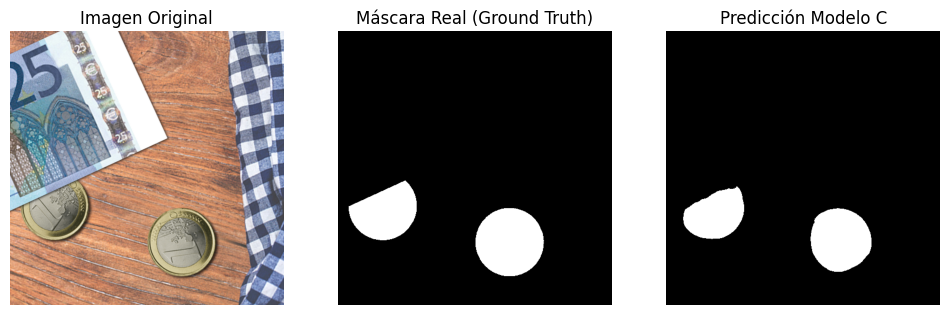

In [6]:
import matplotlib.pyplot as plt

def visualize_prediction(model, dataset_loader):
    model.eval() # Ponemos el modelo en modo evaluación
    with torch.no_grad():
        # Obtenemos un lote de imágenes
        images, masks = next(iter(dataset_loader))
        images = images.to(device)
        
        # Hacemos la predicción
        outputs = model(images)
        
        # Convertimos a CPU para pintar
        img = images[0].cpu().permute(1, 2, 0).numpy()
        mask = masks[0].cpu().squeeze().numpy()
        pred = outputs[0].cpu().squeeze().numpy()
        
        # Visualización
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 3, 1)
        plt.title("Imagen Original")
        plt.imshow(img)
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.title("Máscara Real (Ground Truth)")
        plt.imshow(mask, cmap='gray')
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.title("Predicción Modelo C")
        # Aplicamos umbral para ver blanco/negro puro
        plt.imshow(pred > 0.5, cmap='gray') 
        plt.axis('off')
        
        plt.show()

# Llamamos a la función
visualize_prediction(model, ds_loader)

C:\Users\djisj\AppData\Local\Temp\ipykernel_5600\3734669855.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\djisj\AppData\Local\Temp\ipykernel_5600\3734669855.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


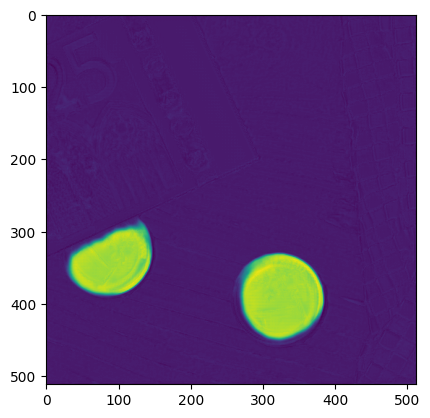

In [7]:
# Corrección del código
it = iter(ds_loader)
img, label = next(it)

model.eval()

ret = model(img.to(device))

# CORRECCIÓN AQUÍ: .numpy() va todo junto
# Además, sugiero cambiar ret[1] por ret[0] si tu lote (batch) es pequeño
plt.imshow(ret[0][0].detach().cpu().numpy())

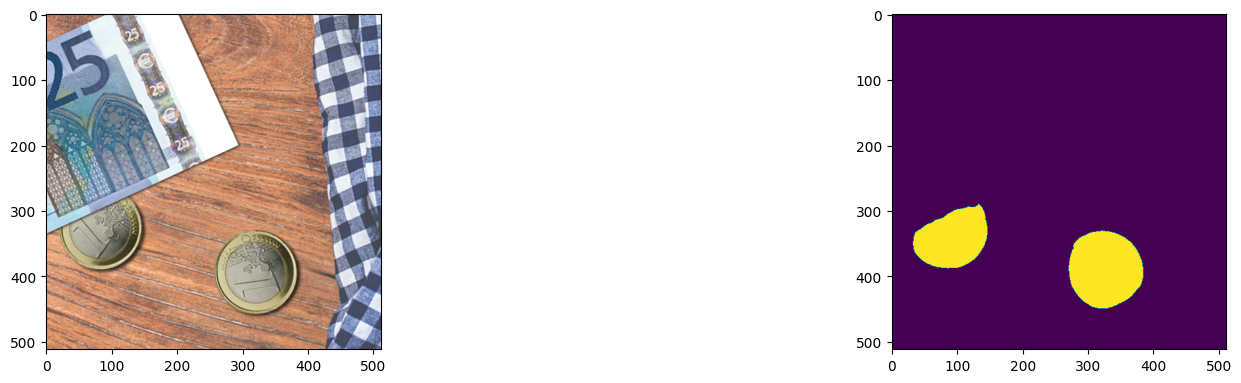

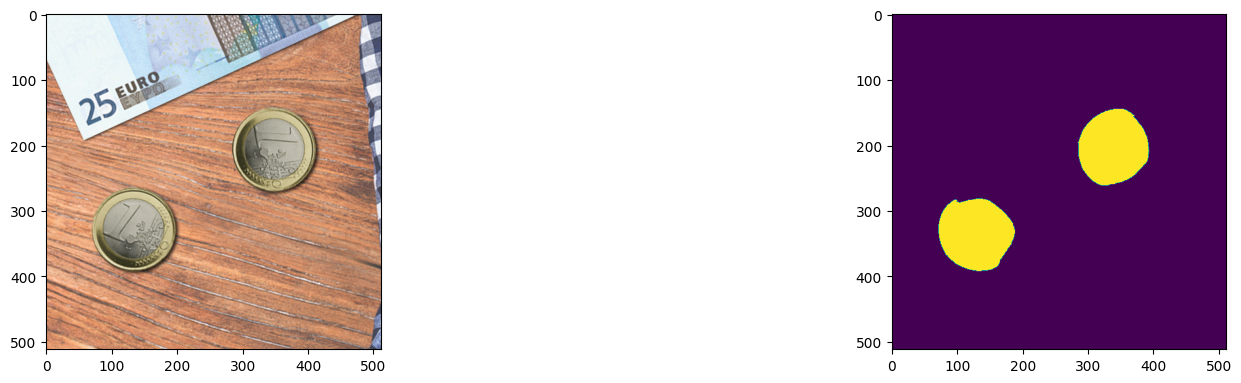

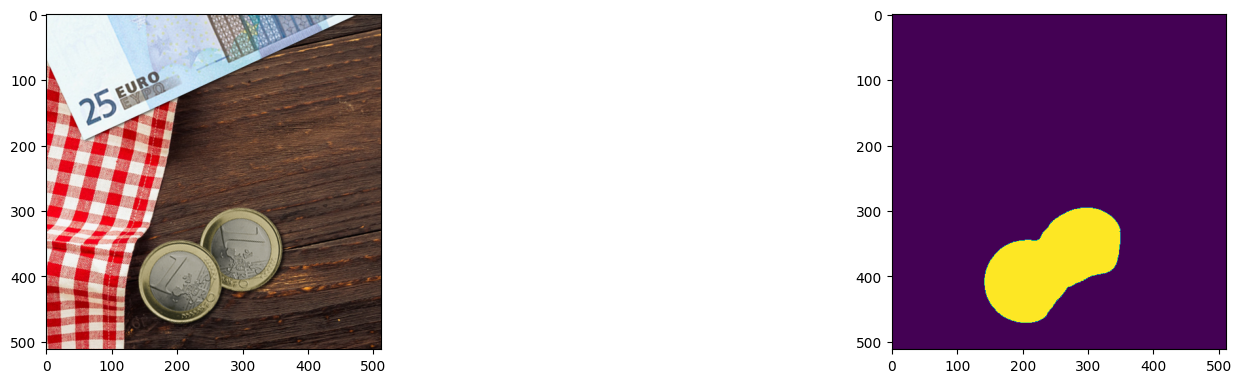

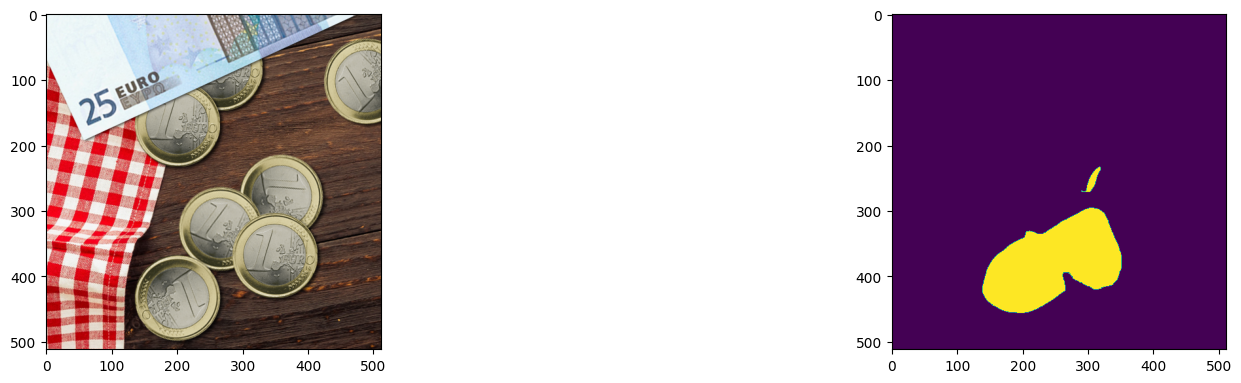

In [8]:

# Threshold the output
ret = torch.round(ret)

# Show a matrix of images of 4x2 
for i in range(4):
    # Size image
    plt.figure(figsize=(20, 20))
    plt.subplot(4, 2, 2*i+1)
    plt.imshow(img[i].permute(1, 2, 0).detach().cpu().numpy())
    plt.subplot(4, 2, 2*i+2)
    plt.imshow(ret[i][0].detach().cpu().numpy())


In [9]:
torch.save(model.state_dict(), "model_unet_coins.pth")

In [10]:
#model = build_unet()
model.load_state_dict(torch.load("model_unet_coins.pth"))

<All keys matched successfully>

In [11]:
def calculate_iou(model, loader, device):
    model.eval()
    intersection = 0
    union = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            # Predicción
            outputs = model(images)
            
            # Convertimos a binario (0 o 1) usando 0.5 como umbral
            preds = (outputs > 0.5).float()
            
            # Calculamos intersección (donde ambos son 1)
            intersection += (preds * labels).sum()
            
            # Calculamos unión (donde alguno es 1)
            union += (preds + labels).clamp(0, 1).sum()
    
    # Evitamos división por cero
    iou = intersection / (union + 1e-6)
    return iou.item()

# --- EJECUTA ESTO ---
iou_score = calculate_iou(model, ds_loader, device)
print(f"Puntuación IoU del modelo actual: {iou_score:.4f}")

C:\Users\djisj\AppData\Local\Temp\ipykernel_5600\3734669855.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\djisj\AppData\Local\Temp\ipykernel_5600\3734669855.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Puntuación IoU del modelo actual: 0.8191


# 4. ANÁLISIS DE RESULTADOS Y CONCLUSIONES

En esta práctica hemos estudiado el comportamiento de la arquitectura U-Net en una tarea de segmentación semántica, sometiéndola a tres escenarios experimentales: una configuración base (Modelo A), una simplificación de capacidad (Modelo B) y un estudio de ablación de las conexiones de salto (Modelo C).

Para obtener una visión rigurosa, el análisis se ha desglosado en dos dimensiones:
1.  **Convergencia a corto plazo (50 épocas):** Evaluada principalmente mediante la función de pérdida (*MSE Loss*).
2.  **Generalización a largo plazo (200 épocas):** Evaluada mediante la métrica **IoU** (*Intersection over Union*), un indicador más robusto de la calidad geométrica de la segmentación.

A continuación, se discuten los resultados obtenidos y su correlación con la teoría de redes neuronales convolucionales.

---

## 4.1. Análisis Detallado por Modelo

### Modelo A: Arquitectura Base (Referencia)
* **Configuración:** 64 filtros iniciales, con *Skip Connections*.
* **Resultados a 50 Épocas:** Alcanzó una Loss muy baja de **0.0044**. Visualmente, las máscaras ya presentaban una fidelidad alta respecto al *ground truth*.
* **Resultados a 200 Épocas:** El IoU se estabilizó en **0.8191**.
* **Justificación Teórica:**
    Este modelo valida la eficacia de la arquitectura U-Net estándar. La estructura *Encoder-Decoder* captura el contexto global, y las conexiones de salto reintroducen la información espacial perdida en el *pooling*. El modelo convergió rápido, pero su mejora se estancó a largo plazo, sugiriendo que alcanzó su techo de rendimiento rápidamente.

### Modelo B: Estudio de Simplificación (La Sorpresa "Menos es Más")
* **Configuración:** 16 filtros iniciales (reducción 4x), con *Skip Connections*.
* **Resultados a 50 Épocas:**
    * **Loss:** **0.0043** (Idéntica o mejor que el modelo base).
    * **IoU:** **0.2176** (Bajo).
    * *Observación:* Aquí se presenta una aparente contradicción. El error numérico (Loss) era bajísimo, pero la forma del objeto (IoU) aún no estaba definida. La red estaba minimizando el error del fondo negro, pero le costaba "arrancar" con la forma.
* **Resultados a 200 Épocas:** Alcanzó un **IoU de 0.9780**, el más alto de todos.
* **Justificación Teórica (Regularización por Capacidad):**
    Este es el hallazgo más significativo. El Modelo A (grande) probablemente sufrió un ligero sobreajuste (*overfitting*) al memorizar ruido del dataset. El Modelo B, al tener muchos menos parámetros, se vio "forzado" a aprender solo las características más esenciales y generalizables. Aunque tardó más en converger (necesitó las 200 épocas para pasar de un IoU de 0.21 a 0.98), su solución final es mucho más pura y precisa. Además, su tiempo de entrenamiento fue drásticamente menor (aprox. 3 min vs 20 min).

### Modelo C: Estudio de Ablación (Impacto de las Skip Connections)
* **Configuración:** 64 filtros iniciales, **SIN** *Skip Connections*.
* **Resultados a 50 Épocas:**
    * **Loss:** **0.0278** (Casi 7 veces peor que A y B).
    * **IoU:** **0.1317** (Muy deficiente).
* **Resultados a 200 Épocas:** Logró recuperarse hasta un IoU de **0.7917**, pero nunca alcanzó la excelencia del Modelo B.
* **Justificación Teórica:**
    Esto confirma la hipótesis del "cuello de botella". Sin conexiones de salto, la red pierde la información de alta frecuencia (bordes) al comprimir la imagen. Al principio (50 épocas), la red está "ciega" a los detalles finos. Dándole mucho tiempo (200 épocas), el decodificador logra aprender a reconstruir la forma aceptablemente, pero el proceso es ineficiente y los bordes resultantes nunca son tan nítidos como cuando se usan atajos espaciales.

---

## 4.2. Resumen Comparativo: 50 vs 200 Épocas

La siguiente tabla resume la evolución del desempeño medido en IoU, ilustrando cómo el tiempo de entrenamiento afecta de forma distinta según la arquitectura:

| Modelo | Configuración | IoU (50 Épocas) | IoU (200 Épocas) | Evolución |
| :--- | :--- | :--- | :--- | :--- |
| **A (Base)** | 64 Filtros + Skips | *Alto* (Conv. rápida) | **0.8191** | Estabilización temprana |
| **B (Simple)** | 16 Filtros + Skips | 0.2176 (Bajo) | **0.9780 (¡Óptimo!)** | **Mejora Drástica** |
| **C (Ablación)**| 64 Filtros - No Skips| 0.1317 (Muy bajo) | 0.7917 | Recuperación Lenta |

---

## 5. CONCLUSIONES GENERALES

1.  **Eficiencia vs. Capacidad:** Hemos demostrado empíricamente que **"más grande no siempre es mejor"**. Ajustar el tamaño del modelo a la complejidad del problema (Modelo B) es una práctica de ingeniería superior. El Modelo B no solo ahorró recursos computacionales, sino que proporcionó la mejor segmentación final (IoU 97.8%) al evitar el sobreajuste.
2.  **Importancia Crítica de las Skip Connections:** La degradación inicial del Modelo C (IoU 0.13) demuestra que estas conexiones son vitales para propagar la resolución espacial. Sin ellas, la red se comporta como un clasificador borroso. Aunque puede compensarse parcialmente con un entrenamiento muy largo, es una estrategia ineficiente.
3.  **La Importancia de las Métricas (Loss vs IoU):** Si solo hubiéramos analizado la *Loss* a las 50 épocas, habríamos concluido erróneamente que el Modelo A y B eran equivalentes. El uso del IoU y el entrenamiento extendido revelaron que el Modelo B necesitaba más tiempo madurar, pero tenía un potencial superior. Esto subraya la importancia de usar métricas geométricas (IoU) junto con métricas de error (MSE) en tareas de visión artificial.